In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jyr0hJYNK8EbOiN20vOR")
project = rf.workspace("marblerace").project("seg-skin")
version = project.version(2)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to seg-skin-2 in yolov8:: 100%|██████████| 4139/4139 [00:00<00:00, 6479.14it/s]


In [2]:
!pip install ultralytics -q
from ultralytics import YOLO
model_seg = YOLO("yolov8s-seg.pt")

results_seg = model_seg.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    name = "affected skin segmentation"
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/seg-skin-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dy

In [3]:
metrics_seg = model_seg.val(
    data=f"{dataset.location}/data.yaml",
    split="test"

)
seg_accuracy_equivalent = metrics_seg.seg.map

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 5.2±1.7 MB/s, size: 28.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/seg-skin-2/test/labels... 162 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 162/162 359.8it/s 0.5s
val: New cache created: /content/seg-skin-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.6it/s 6.9s
                   all        162        162      0.992      0.975      0.993      0.782      0.998      0.981      0.995       0.74
Speed: 5.4ms preprocess, 14.9ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to 

Segmentation:


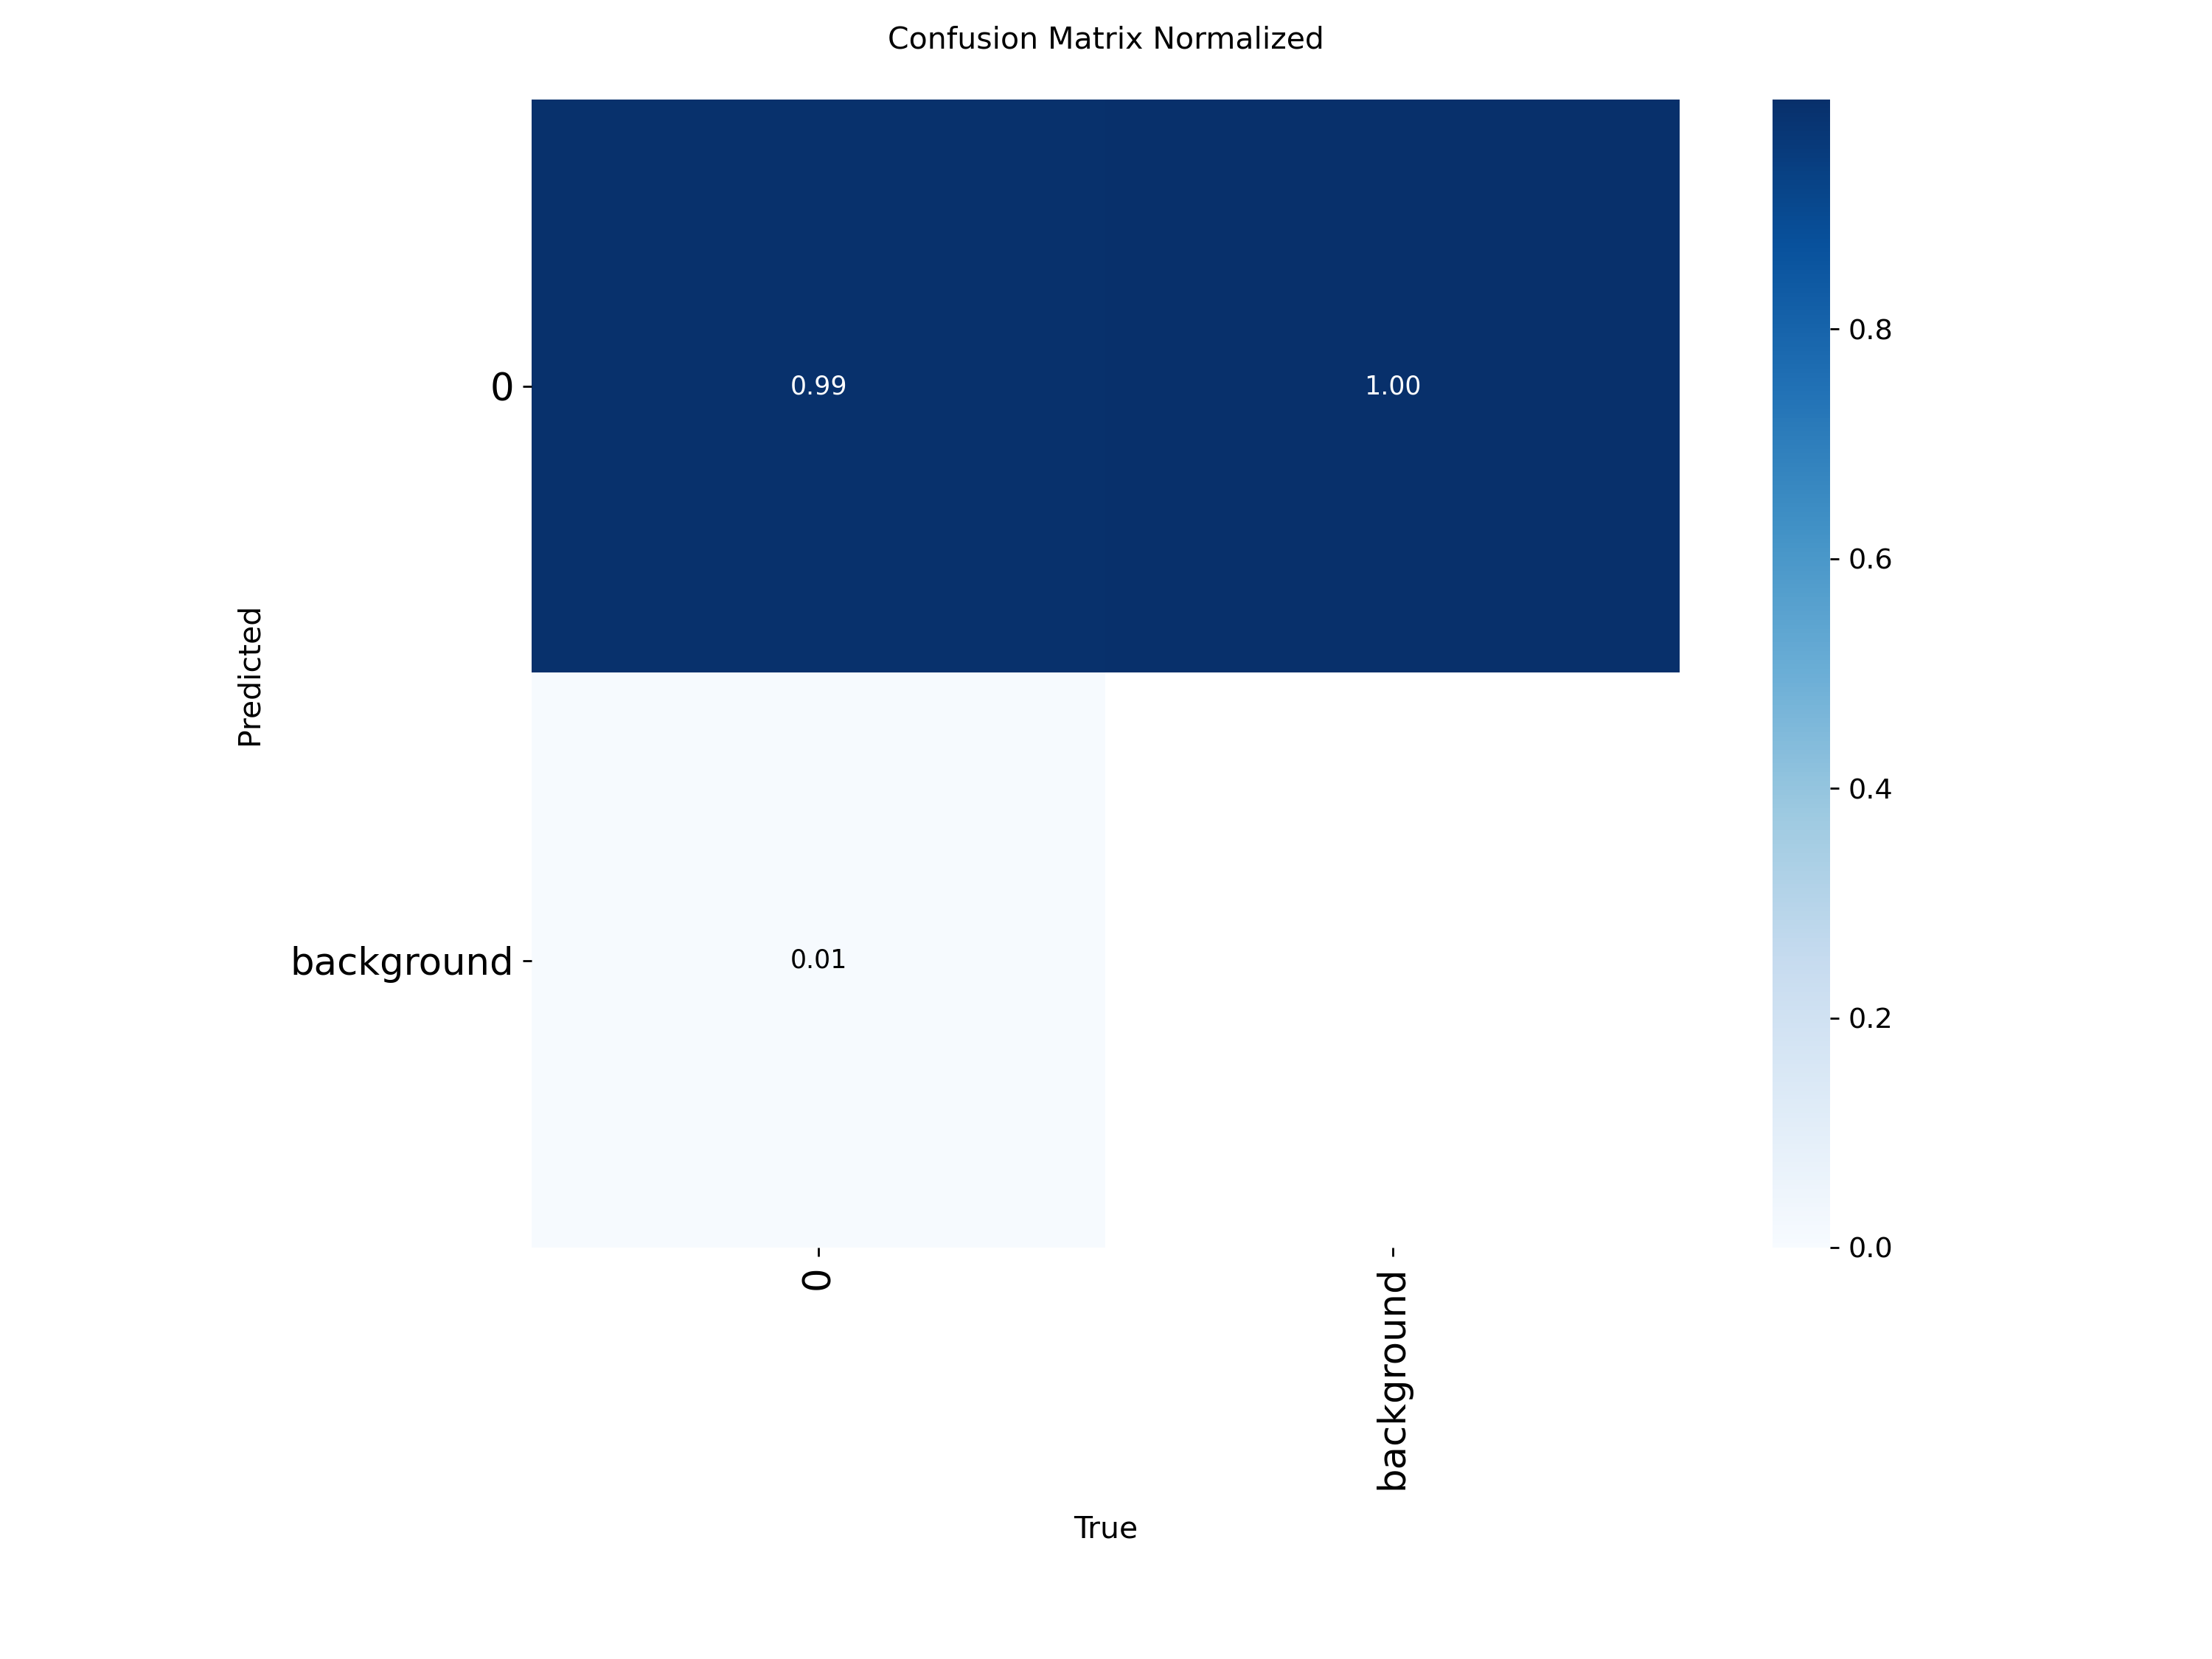

In [4]:
from IPython.display import Image, display
print("Segmentation:")
display(Image("/content/runs/segment/val/confusion_matrix_normalized.png"))

Results saved to: /content/runs/segment/affected skin segmentation


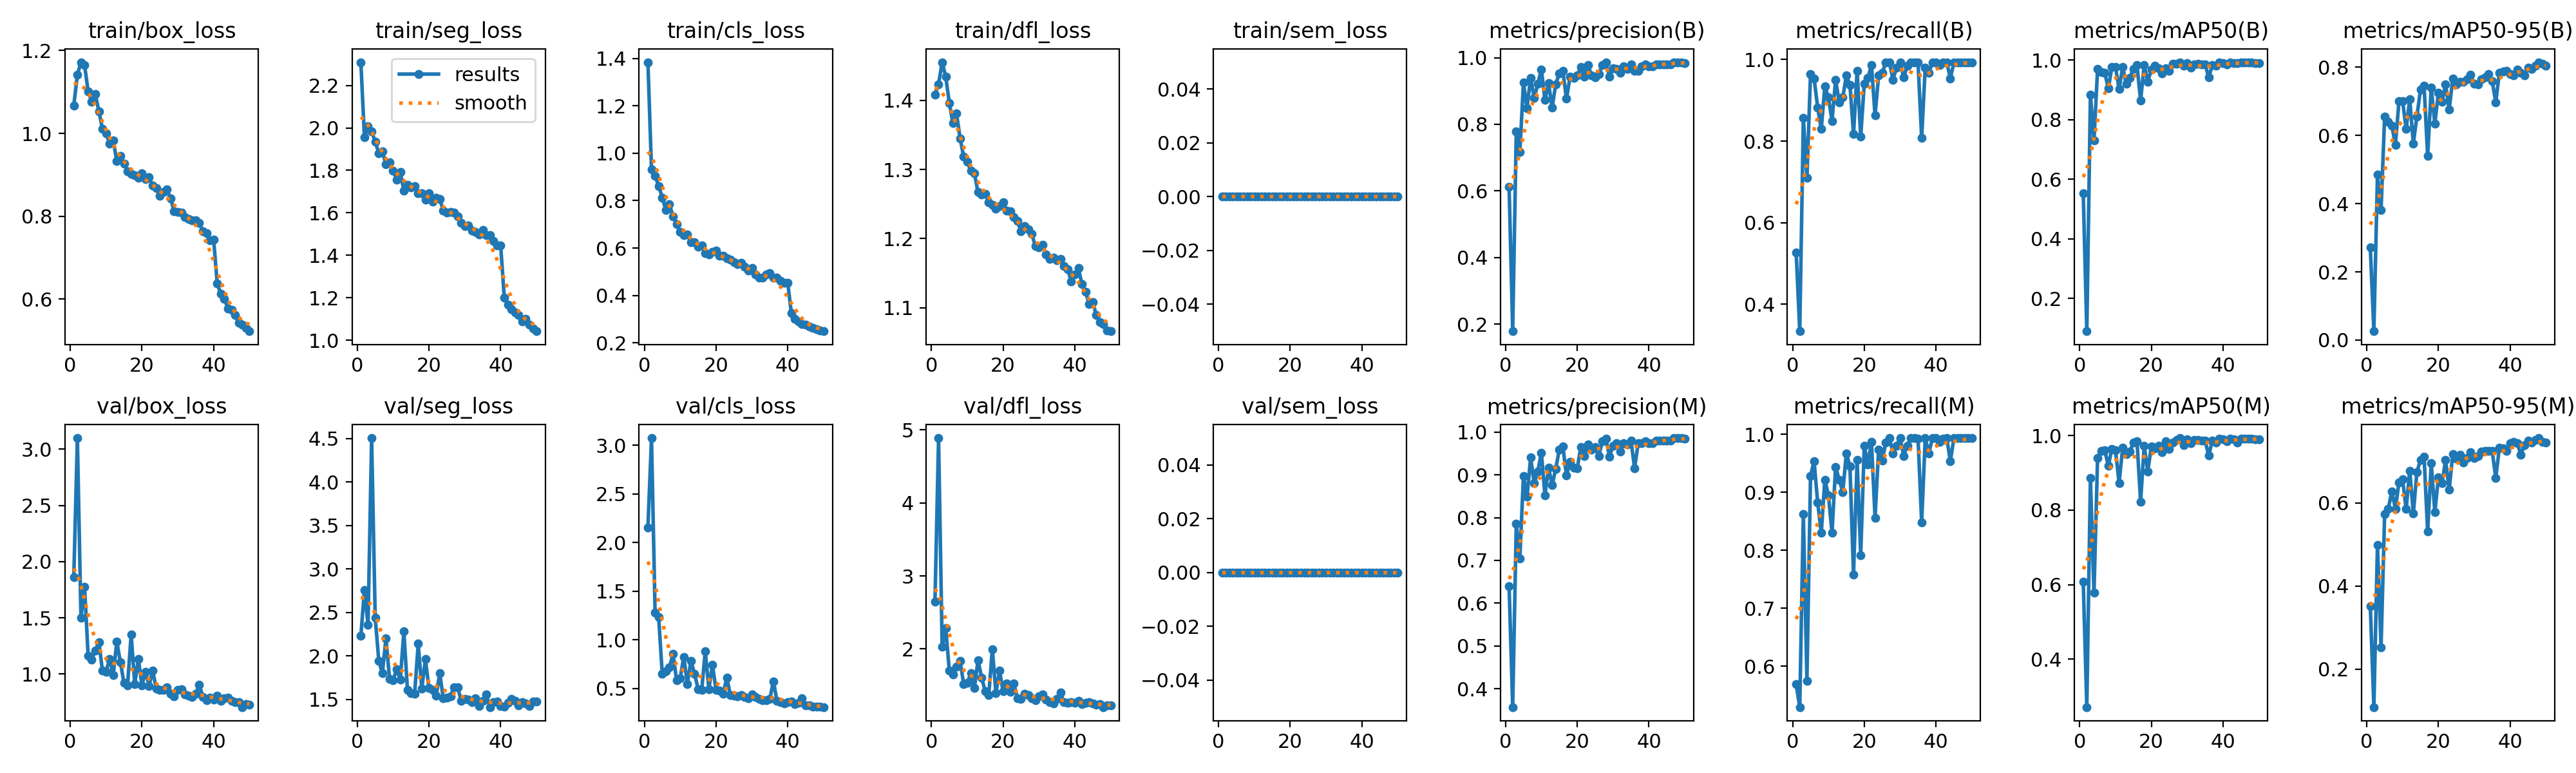

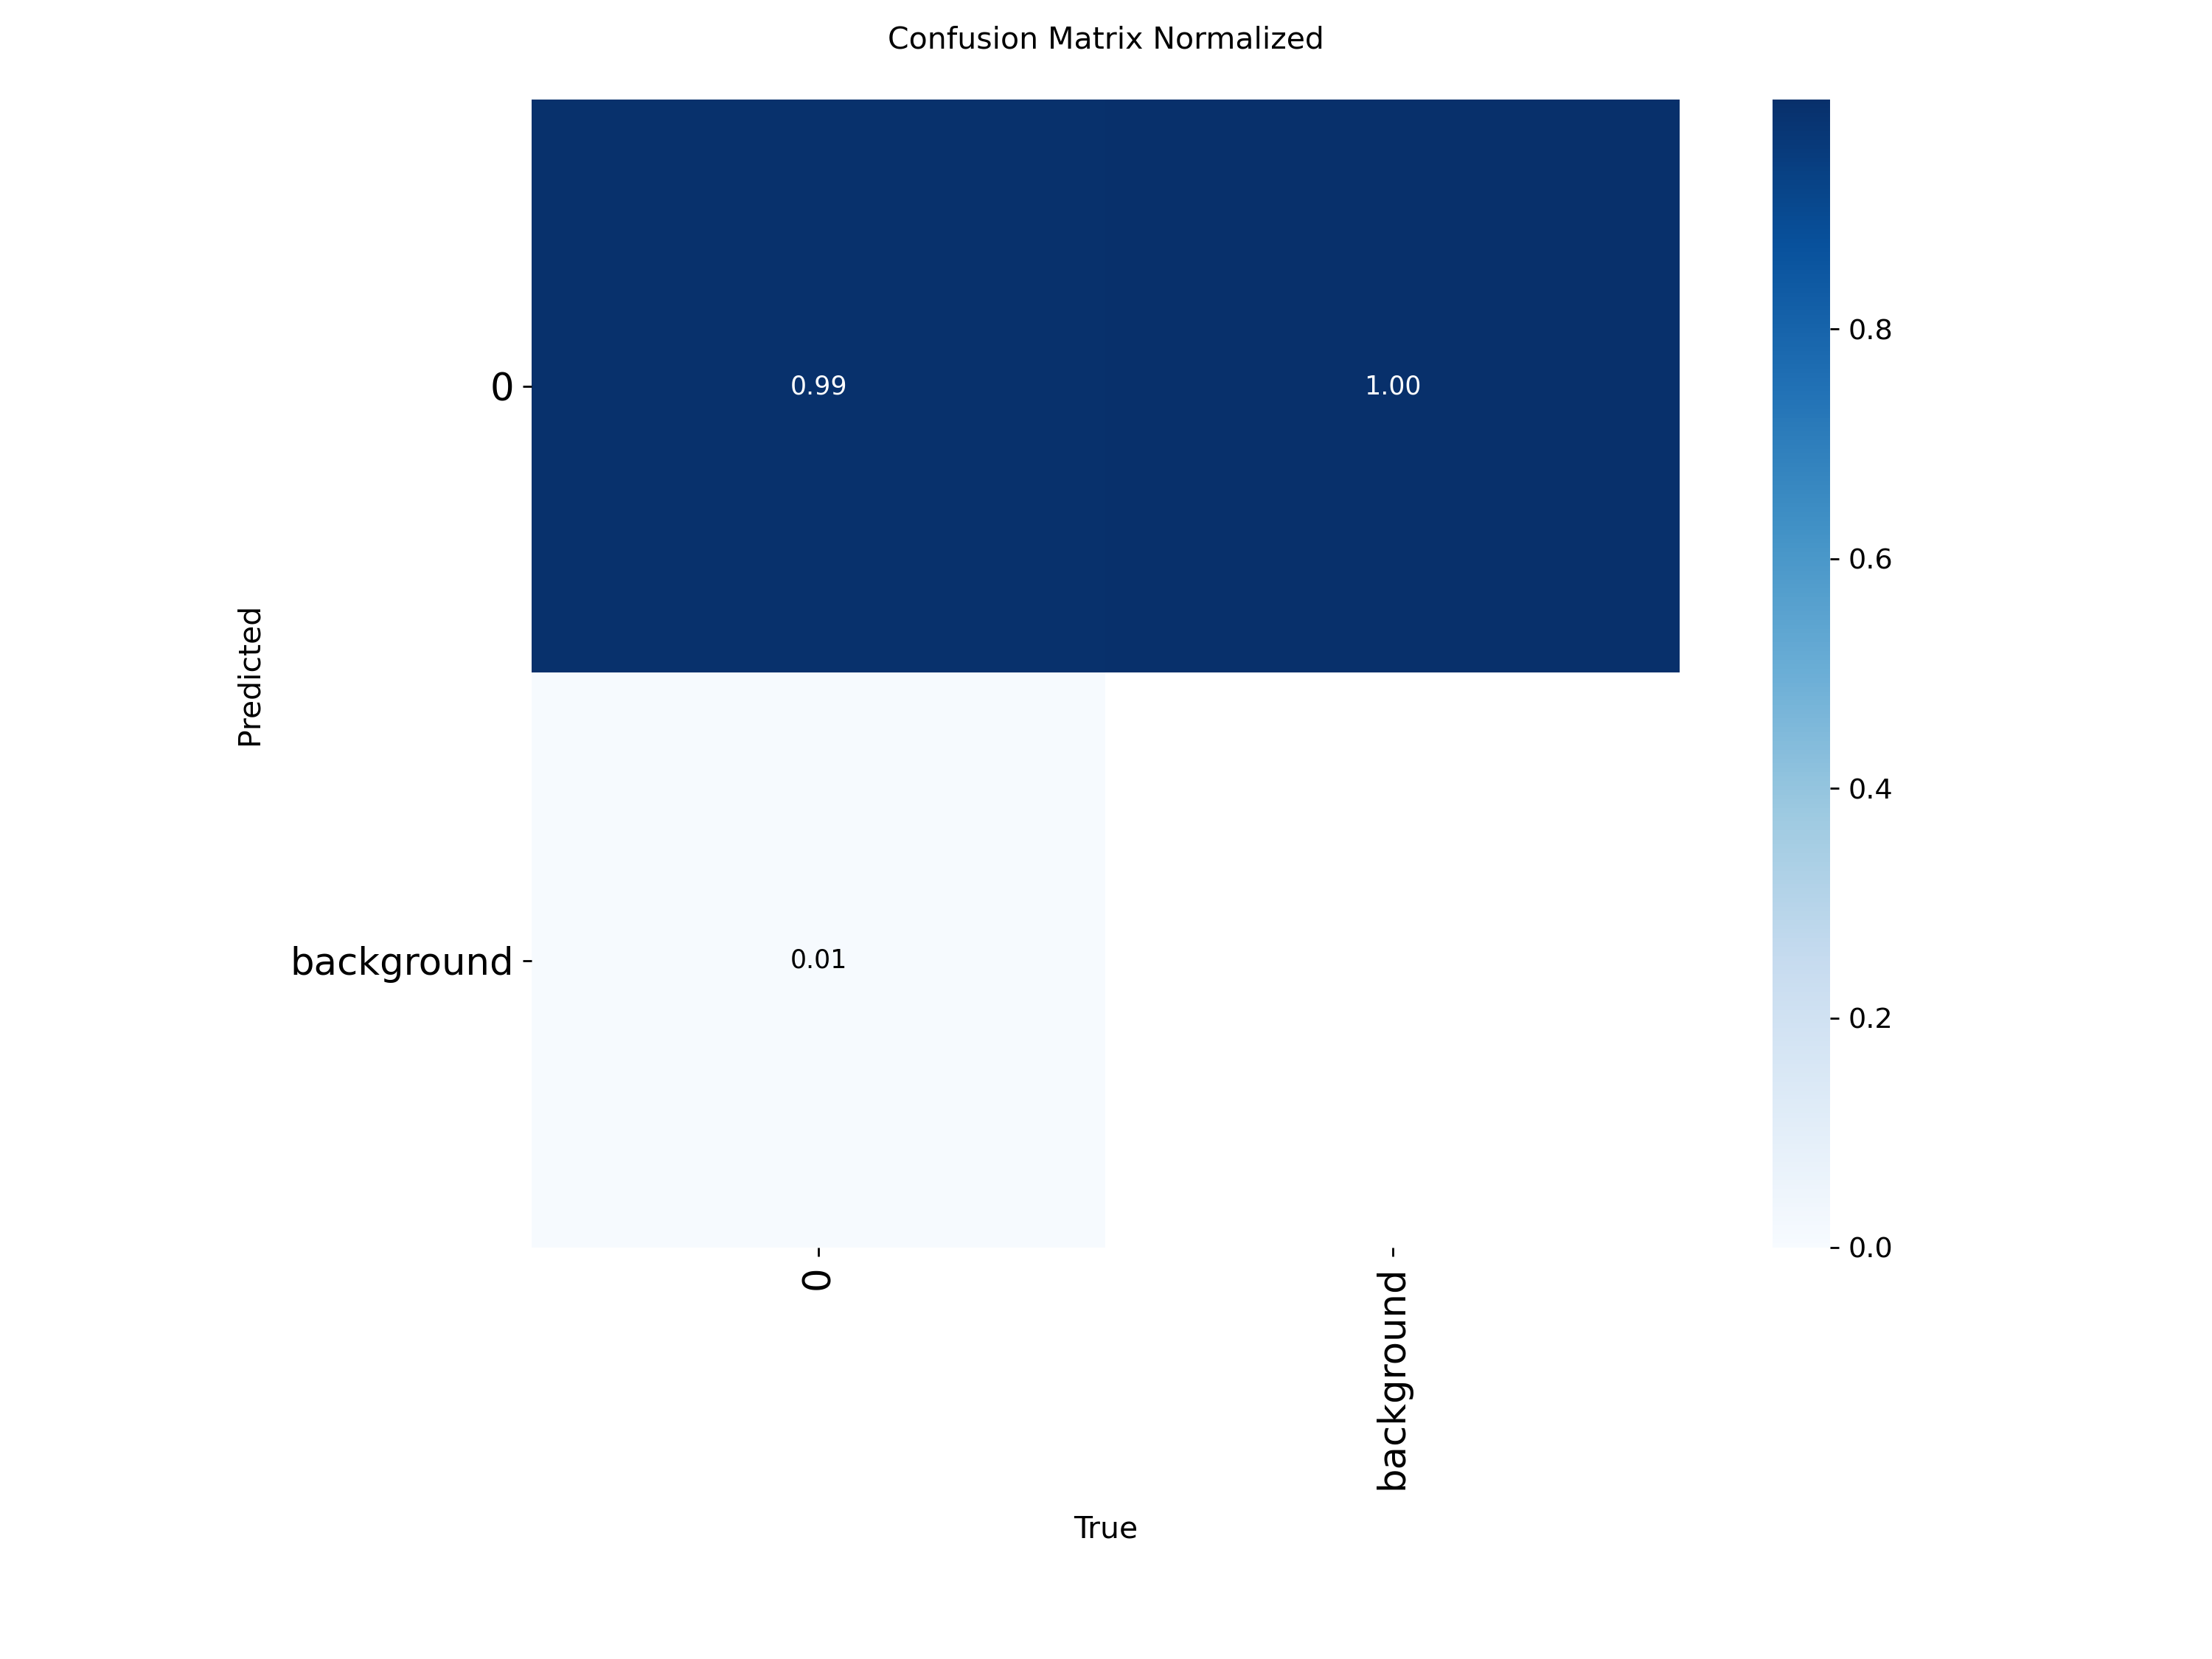

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ---------------------------
# 1. Ultralytics tells you exactly where results were saved
# ---------------------------
save_dir = results_seg.save_dir   # e.g. runs/classify/skin_classification
print(f"Results saved to: {save_dir}")

# ---------------------------
# 2. View the auto-generated graphs directly (no need to recreate them)
# ---------------------------
display(Image(f"{save_dir}/results.png"))
display(Image(f"{save_dir}/confusion_matrix_normalized.png"))

In [6]:
import os
print(os.listdir(save_dir))


['BoxF1_curve.png', 'train_batch1.jpg', 'results.png', 'confusion_matrix.png', 'weights', 'BoxPR_curve.png', 'labels.jpg', 'val_batch1_pred.jpg', 'MaskR_curve.png', 'val_batch0_labels.jpg', 'train_batch4400.jpg', 'confusion_matrix_normalized.png', 'train_batch2.jpg', 'train_batch4401.jpg', 'train_batch4402.jpg', 'val_batch1_labels.jpg', 'MaskP_curve.png', 'val_batch2_labels.jpg', 'args.yaml', 'train_batch0.jpg', 'MaskPR_curve.png', 'BoxP_curve.png', 'results.csv', 'MaskF1_curve.png', 'BoxR_curve.png', 'val_batch0_pred.jpg', 'val_batch2_pred.jpg']


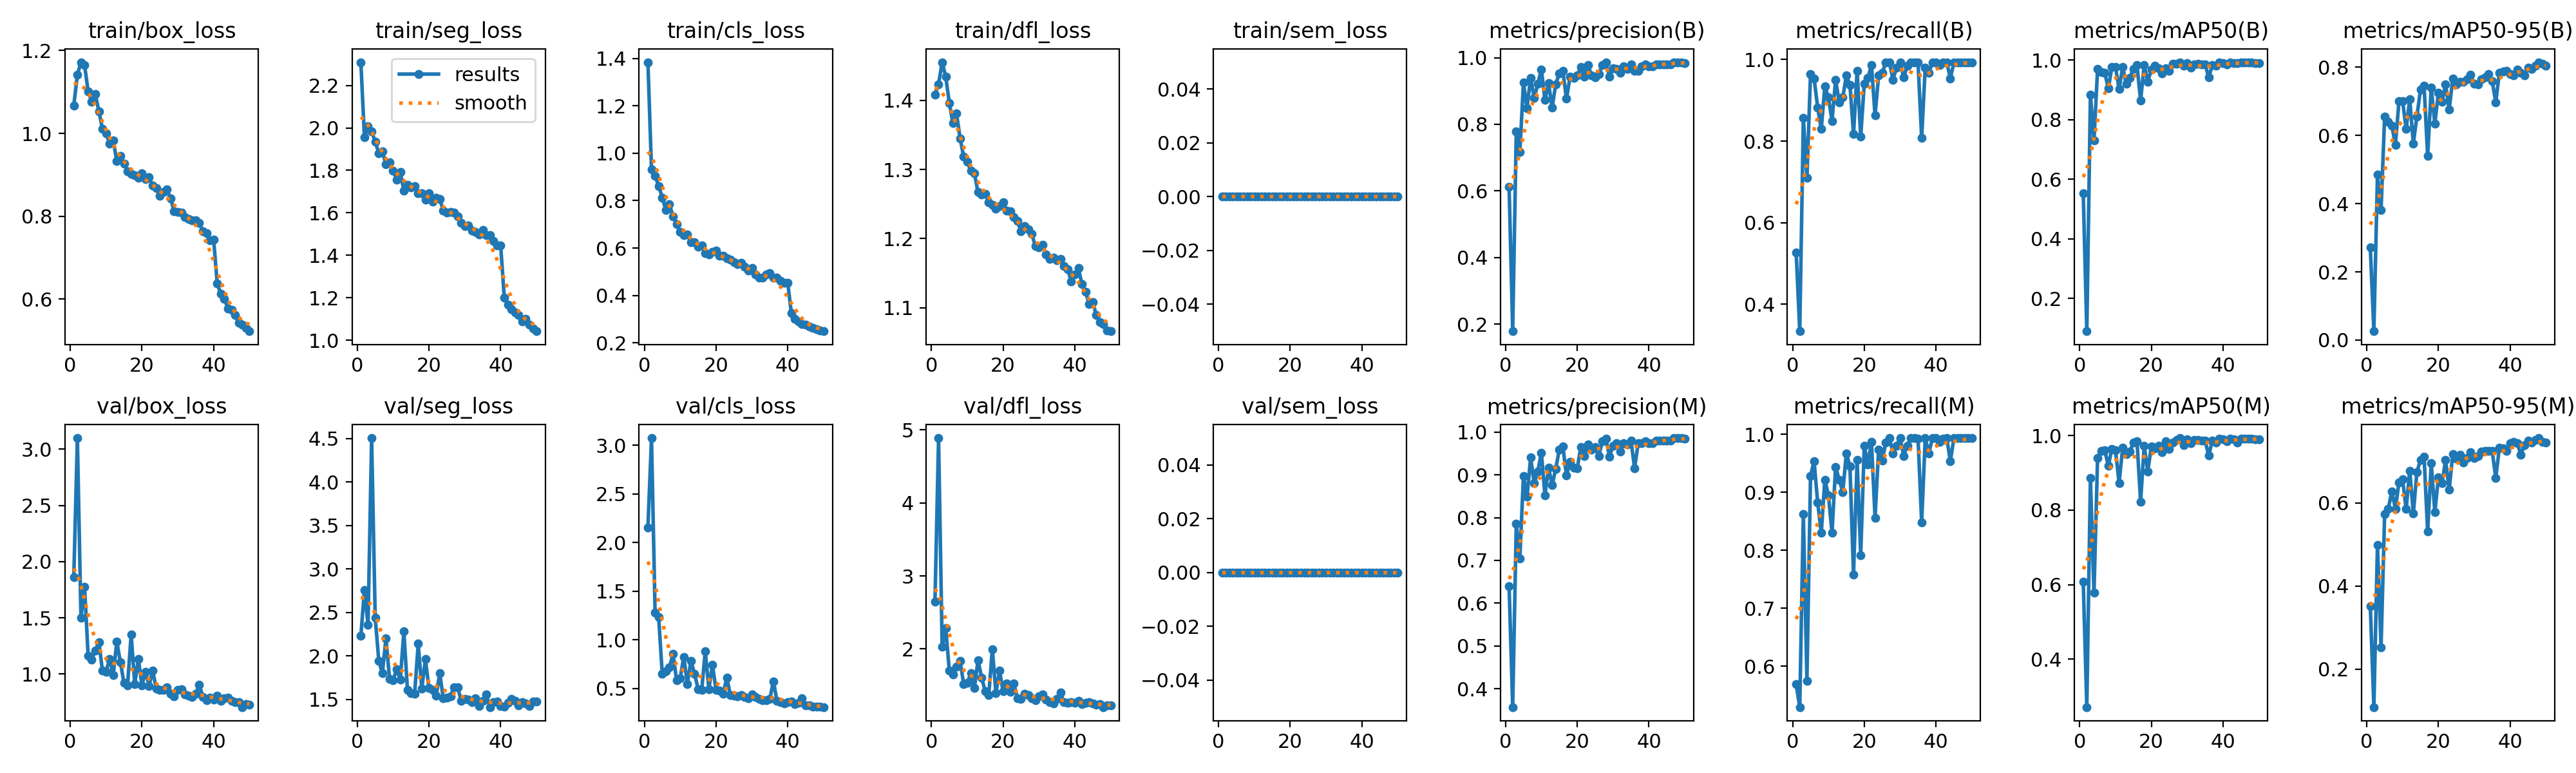

In [7]:
from IPython.display import Image, display
display(Image(filename=f"{save_dir}/results.png"))